<a href="https://colab.research.google.com/github/Prateek07-ai/Churn_model/blob/main/Churn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing the Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Imbalance handling
from imblearn.over_sampling import SMOTE
from collections import Counter

# Model
from xgboost import XGBClassifier

# Save model
import joblib

### Loding the Dataset

In [72]:
data = pd.read_csv("/content/telco_cuctomer_data.csv")
print(data.head())

   Unnamed: 0  customerID  gender SeniorCitizen Partner Dependents  tenure  \
0           0  7590-VHVEG  Female            No     Yes         No       1   
1           1  5575-GNVDE    Male            No      No         No      34   
2           2  3668-QPYBK    Male            No      No         No       2   
3           3  7795-CFOCW    Male            No      No         No      45   
4           4  9237-HQITU  Female            No      No         No       2   

  PhoneService     MultipleLines InternetService  ... DeviceProtection  \
0           No  No phone service             DSL  ...               No   
1          Yes                No             DSL  ...              Yes   
2          Yes                No             DSL  ...               No   
3           No  No phone service             DSL  ...              Yes   
4          Yes                No     Fiber optic  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0       

### Cleaning the data

Removing the ID column

In [73]:
data = data.drop("customerID", axis=1)
# Drop 'Unnamed: 0' column if it exists, as it's often a redundant index
if 'Unnamed: 0' in data.columns:
    data = data.drop("Unnamed: 0", axis=1)

Convert TotalCharges to numeric

In [74]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors='coerce')
# Drop rows only where 'TotalCharges' is NaN to avoid losing other valid data
data = data.dropna(subset=["TotalCharges"])

Encoding the Target

In [103]:
data["Churn"] = data["Churn"].map({"Churned":1, "Stayed":0})

### Encoding the Categorical Variables


In [105]:
X = pd.get_dummies(X, drop_first=True)

### Spliting the Fetures & Target

In [104]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

### Train-Test Split

In [106]:
X_train, X_test,y_train,y_test=train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Feature Scaling

In [107]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Handling the class imbalance using SMOTE

In [108]:
print("Before SMOTE :", Counter(y_train))

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train_sm))

Before SMOTE : Counter({0: 4130, 1: 1495})
After SMOTE: Counter({0: 4130, 1: 4130})


### Train XGBoost Model

In [110]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train_sm, y_train_sm.values.astype(int))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:59:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

### Prediction

In [111]:
y_pre = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]

### Model Evaluation

Classification Report

In [116]:
print(classification_report(y_test, y_pre))

              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1033
           1       0.59      0.64      0.62       374

    accuracy                           0.79      1407
   macro avg       0.73      0.74      0.73      1407
weighted avg       0.79      0.79      0.79      1407



### Confusion Matrix

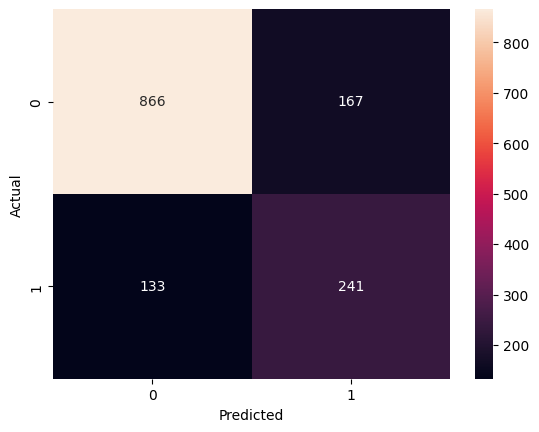

In [117]:
cm = confusion_matrix(y_test, y_pre)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

ROC-AUC Score

In [118]:
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

ROC-AUC Score: 0.8261384990500644


### Feature Importance

In [119]:
importances = pd.Series(xgb.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(10))

Contract_Two year                 0.277734
Contract_One year                 0.208699
InternetService_Fiber optic       0.103288
InternetService_No                0.058043
StreamingMovies_Yes               0.035399
MultipleLines_Yes                 0.030602
PaperlessBilling_Yes              0.025091
OnlineSecurity_Yes                0.024937
PaymentMethod_Electronic check    0.024736
gender_Male                       0.021642
dtype: float32


### Save Model and Scaler

In [123]:
joblib.dump(xgb, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

In [124]:
!zip -r churn_project.zip .

	zip warning: name not matched: drive/MyDrive/prateek Mukherjee 10,E 31 .pdf
  adding: .config/ (stored 0%)
  adding: .config/gce (stored 0%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/configurations/ (stored 0%)
  adding: .config/configurations/config_default (deflated 15%)
  adding: .config/.last_survey_prompt.yaml (stored 0%)
  adding: .config/active_config (stored 0%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/config_sentinel (stored 0%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2026.01.16/ (stored 0%)
  adding: .config/logs/2026.01.16/14.24.03.314209.log (deflated 58%)
  adding: .config/logs/2026.01.16/14.24.18.954466.log (deflated 58%)
  adding: .config/logs/2026.01.16/14.24.28.646070.log (deflated 57%)
  adding: .config/logs/2026.01.16/14.24.29.392089.log (deflated 56%)
  adding: .config/logs/2026.01.16/14.24.13.071214.log (deflated 87%)
  adding: .config/logs/2026.01.16/14.23.31.981136.log (deflated 92%)


In [125]:
from google.colab import files
files.download("churn_project.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>